In [25]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.decomposition import PCA
from matplotlib.ticker import StrMethodFormatter

In [26]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
np.set_printoptions(suppress = True)
np.set_printoptions(precision = 2)

In [27]:
raw = "C:\\Users\\taavi\\Desktop\\BPHIL\\Raw data\\"
clean = "C:\\Users\\taavi\\Desktop\\BPHIL\\Clean data\\"
images = 'C:\\Users\\taavi\\Desktop\\BPHIL\\Images in defense ppt\\'

In [37]:
parcels = pd.read_csv(clean + 'blight.csv')

In [39]:
values = pd.read_csv(clean + 'clean_values.csv')

### Make parcels time-sensitive

In [40]:
years = pd.date_range(start = values['year'].min(), end = '2026-12-31', freq = 'Y')

In [41]:
parcels = parcels.merge(pd.DataFrame({'date': years}), how = 'cross').sort_values(by = 'date').reset_index(drop = True)
parcels['date'] = parcels['date'].dt.year
parcels = parcels.rename(columns = {'date': 'year'})

### Get yearly values for each parcel

In [42]:
years = range(values['year'].min(), values['year'].max() + 1)

In [43]:
full = pd.DataFrame()

earthRadius = 6_378_137 # meters

distances = np.arange(50, 800, 50)
distances_radians = distances / earthRadius
weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]

for year in tqdm(years):
    parcels_sub = parcels.loc[parcels['year'] == year].reset_index(drop = True)
    values_sub = values.loc[values['year'] == year].reset_index(drop = True)

    parcels_coords = np.radians(parcels_sub[['lat', 'lng']].to_numpy())
    values_coords = np.radians(values_sub[['lat', 'lng']].to_numpy())

    value_tree = BallTree(values_coords, metric = 'haversine')
    
    # count and sum values in each distance bin
    for d_m, d_r in zip(distances, distances_radians):
        indices_within_radius = value_tree.query_radius(parcels_coords, r = d_r)
        counts = [len(idxs) for idxs in indices_within_radius]
        parcels_sub[f'values_count_{d_m}'] = counts

        sums = [values_sub.loc[idxs, 'value'].sum() for idxs in indices_within_radius]
        parcels_sub[f'values_sum_{d_m}'] = sums

    parcels_sub = parcels_sub.fillna(0)

    for i, r in enumerate(distances[::-1]):
        if r != distances[0]:
            parcels_sub[f'values_count_{r}'] -= parcels_sub[f'values_count_{distances[::-1][i + 1]}']
            parcels_sub[f'values_sum_{r}'] -= parcels_sub[f'values_sum_{distances[::-1][i + 1]}']
    
    parcels_sub['values_count_decayed'] = (parcels_sub.iloc[:, -len(distances) * 2::2] * weights).sum(axis = 1)
    parcels_sub['values_sum_decayed'] = (parcels_sub.iloc[:, -len(distances) * 2::2] * weights).sum(axis = 1)

    parcels_sub['values_decayed'] = parcels_sub['values_sum_decayed'] / parcels_sub['values_count_decayed']

    train = parcels_sub.loc[(parcels_sub['values_decayed'].isna() == False)]
    x = train[['lat', 'lng']]
    y = train['values_decayed']

    knn = KNeighborsRegressor(n_neighbors = 5)
    parcels_sub.loc[
        (parcels_sub['values_decayed'].isna()) | (parcels_sub['values_decayed'] == 0), 'values_decayed'
        ]= knn.fit(x, y).predict(parcels_sub.loc[(parcels_sub['values_decayed'].isna()) | (parcels_sub['values_decayed'] == 0), ['lat', 'lng']])

    full = pd.concat([full, parcels_sub], axis = 0)

full = full.reset_index(drop = True)

100%|██████████| 10/10 [1:26:23<00:00, 518.34s/it]


In [44]:
parcels = full.copy()

In [45]:
parcels.to_csv(clean + 'values_decayed.csv', index = False)

In [46]:
parcels = pd.read_csv(clean + 'values_decayed.csv')

In [47]:
row_two = parcels.iloc[10_000:10_002].copy()[['parcelID', 'lat', 'lng', 'nbrhd', 'values_count_50', 'values_sum_50', 'values_count_100', 'values_sum_100']].copy()
row_one = (
    row_two
    .assign(
        values_count_100 = (row_two['values_count_100'] + row_two['values_count_50']),
        values_sum_100 = (row_two['values_sum_100'] + row_two['values_sum_50'])
    )
    .copy()
)
row_three = (
    row_two
    .assign(
        values_count_50 = row_two['values_count_50'] * (15/15),
        values_sum_50 = row_two['values_sum_50'] * (15/15),
        values_count_100 = row_two['values_count_100'] * (14/15),
        values_sum_100 = row_two['values_sum_100'] * (14/15)
    )
    .copy()
)

pd.concat([row_one, row_two, row_three], axis = 0).iloc[::2].assign(process = ['raw_count_and_sum', 'annuli_adjustment', 'distance_decay']).set_index('process')

,parcelID,lat,lng,nbrhd,values_count_50,values_sum_50,values_count_100,values_sum_100
process,,,,,,,,
raw_count_and_sum,0045A00007000000,40.47,-80.03,Marshall-Shadeland,2.00,"100,000.00",6.00,"256,675.00"
annuli_adjustment,0045A00007000000,40.47,-80.03,Marshall-Shadeland,2.00,"100,000.00",4.00,"156,675.00"
distance_decay,0045A00007000000,40.47,-80.03,Marshall-Shadeland,2.00,"100,000.00",3.73,"146,230.00"


### Imputing nulls, 5-years past smoothing, diff and pct_change, and some column cleanup

In [48]:
parcels = parcels.sort_values(by = ['parcelID', 'year']).reset_index(drop = True)

same_parcel_prev_1 = parcels['parcelID'].eq(parcels['parcelID'].shift(1))
same_parcel_prev_2 = parcels['parcelID'].eq(parcels['parcelID'].shift(2))
same_parcel_prev_3 = parcels['parcelID'].eq(parcels['parcelID'].shift(3))
same_parcel_prev_4 = parcels['parcelID'].eq(parcels['parcelID'].shift(4))
same_parcel_prev_5 = parcels['parcelID'].eq(parcels['parcelID'].shift(5))

parcels = (
    parcels
    .assign(
        past_1 = parcels['values_decayed'].shift(1).where(same_parcel_prev_1),
        past_2 = parcels['values_decayed'].shift(2).where(same_parcel_prev_2),
        past_3 = parcels['values_decayed'].shift(3).where(same_parcel_prev_3),
        past_4 = parcels['values_decayed'].shift(4).where(same_parcel_prev_4),
        past_5 = parcels['values_decayed'].shift(5).where(same_parcel_prev_5),
    )
    .assign(
        values_smoothed = lambda x: pd.concat([x['values_decayed'], x['past_1'], x['past_2'], x['past_3'], x['past_4'], x['past_5']], axis = 1).mean(axis = 1)
    )
    .assign(
        nom_delta_1 = lambda x: x['values_smoothed'].diff(1).where(same_parcel_prev_1).shift(-1),
        nom_delta_2 = lambda x: x['values_smoothed'].diff(2).where(same_parcel_prev_2).shift(-2),
        nom_delta_3 = lambda x: x['values_smoothed'].diff(3).where(same_parcel_prev_3).shift(-3),
        nom_delta_4 = lambda x: x['values_smoothed'].diff(4).where(same_parcel_prev_4).shift(-4),
        nom_delta_5 = lambda x: x['values_smoothed'].diff(5).where(same_parcel_prev_5).shift(-5),
        pct_delta_1 = lambda x: x['values_smoothed'].pct_change(1).where(same_parcel_prev_1).shift(-1),
        pct_delta_2 = lambda x: x['values_smoothed'].pct_change(2).where(same_parcel_prev_2).shift(-2),
        pct_delta_3 = lambda x: x['values_smoothed'].pct_change(3).where(same_parcel_prev_3).shift(-3),
        pct_delta_4 = lambda x: x['values_smoothed'].pct_change(4).where(same_parcel_prev_4).shift(-4),
        pct_delta_5 = lambda x: x['values_smoothed'].pct_change(5).where(same_parcel_prev_5).shift(-5),
    )
    .assign(
        cagr_1 = lambda x: ((x['pct_delta_1'] + 1) ** (1/1)) - 1,
        cagr_2 = lambda x: ((x['pct_delta_2'] + 1) ** (1/2)) - 1,
        cagr_3 = lambda x: ((x['pct_delta_3'] + 1) ** (1/3)) - 1,
        cagr_4 = lambda x: ((x['pct_delta_4'] + 1) ** (1/4)) - 1,
        cagr_5 = lambda x: ((x['pct_delta_5'] + 1) ** (1/5)) - 1
    )
    .reset_index(drop = True)
    [['parcelID', 'lat', 'lng', 'year',
      'blight_sqrt',#'blight', 
      'viols_count_decayed', 'low_count_decayed', 'high_count_decayed', 'values_decayed', 'values_smoothed',
      'viols_sqrt', 'low_sqrt', 'high_sqrt',
      'nom_delta_1', 'nom_delta_2', 'nom_delta_3', 'nom_delta_4', 'nom_delta_5',
      'pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5',
      'cagr_1', 'cagr_2', 'cagr_3', 'cagr_4', 'cagr_5']]
)

In [54]:
print('MEAN')
print(parcels[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].mean())
print('STDEV')
print(parcels[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].std())
print('\n')
print('MEDIAN')
print(parcels[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].median())
print('IQR')
print(parcels[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].quantile(0.75) -
      parcels[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].quantile(0.25))

MEAN
pct_delta_1   1.04
pct_delta_2   0.93
pct_delta_3   1.03
pct_delta_4   1.15
pct_delta_5   1.34
dtype: float64
STDEV
pct_delta_1   231.92
pct_delta_2   167.73
pct_delta_3   147.72
pct_delta_4   138.83
pct_delta_5   139.67
dtype: float64


MEDIAN
pct_delta_1   0.05
pct_delta_2   0.11
pct_delta_3   0.17
pct_delta_4   0.26
pct_delta_5   0.34
dtype: float64
IQR
pct_delta_1   0.10
pct_delta_2   0.18
pct_delta_3   0.26
pct_delta_4   0.34
pct_delta_5   0.44
dtype: float64


### Commentary:

There certainly are outliers and parts of the data look tremendously out of wack - but at scale I think it's appropriate

### Comparing values and blight

In [28]:
parcels_regression = (
    parcels
    .loc[parcels['year'] >= 2020]
    .assign(
        mean_value = lambda x: x.groupby('parcelID')['values_smoothed'].transform('mean')
    )
    .drop_duplicates(subset = 'parcelID')
)

In [29]:
model = smf.ols(formula = 'mean_value ~ viols_sqrt + low_sqrt + high_sqrt', data = parcels_regression).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_value   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                 2.511e+04
Date:                Thu, 11 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:01:33   Log-Likelihood:            -1.9020e+06
No. Observations:              144031   AIC:                         3.804e+06
Df Residuals:                  144027   BIC:                         3.804e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.743e+05   1072.446    162.542      0.0

In [33]:
model = smf.ols(formula = 'mean_value ~ C(blight_sqrt)', data = parcels_regression).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_value   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     8196.
Date:                Thu, 11 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:12:57   Log-Likelihood:            -1.9112e+06
No. Observations:              144031   AIC:                         3.822e+06
Df Residuals:                  144024   BIC:                         3.822e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.965e+05    

In [34]:
anova_results = anova_lm(model)
print(anova_results)

                       df                   sum_sq                mean_sq  \
C(blight_sqrt)       6.00   965,677,730,555,301.00 160,946,288,425,883.50   
Residual       144,024.00 2,828,177,416,683,935.00      19,636,848,141.17   

                      F  PR(>F)  
C(blight_sqrt) 8,196.14    0.00  
Residual            NaN     NaN  


In [61]:
toMerge = pd.read_csv(clean + 'clean_parcels.csv')
parcels = parcels.merge(right = toMerge[['parcelID', 'nbrhd']], on = 'parcelID', how = 'left')

In [ ]:
parcels.to_csv(clean + 'blight_and_values.csv', index = False)

In [28]:
parcels = pd.read_csv(clean + 'blight_and_values.csv')

### Blight, Neighborhood, & Blight + Neighborhood regressions

In [6]:
parcels_regression = (
    parcels
    .loc[parcels['year'] >= 2020]
    .assign(
        mean_value = lambda x: x.groupby('parcelID')['values_smoothed'].transform('mean')
    )
    .drop_duplicates(subset = 'parcelID')
)

In [21]:
model = smf.ols(formula = 'mean_value ~ C(blight_sqrt)', data = parcels_regression).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_value   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     7787.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:58:30   Log-Likelihood:            -1.9121e+06
No. Observations:              144031   AIC:                         3.824e+06
Df Residuals:                  144024   BIC:                         3.824e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.942e+05   1

In [22]:
model = smf.ols(formula = 'mean_value ~ C(nbrhd)', data = parcels_regression).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_value   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     8531.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:58:35   Log-Likelihood:            -1.8001e+06
No. Observations:              144031   AIC:                         3.600e+06
Df Residuals:                  143941   BIC:                         3.601e+06
Df Model:                          89                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [23]:
model = smf.ols(formula = 'mean_value ~ C(nbrhd) + C(blight_sqrt)', data = parcels_regression).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_value   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     8546.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:58:46   Log-Likelihood:            -1.7960e+06
No. Observations:              144031   AIC:                         3.592e+06
Df Residuals:                  143935   BIC:                         3.593e+06
Df Model:                          95                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [7]:
(
    parcels
    .groupby('parcelID')[[f'pct_delta_{i}' for i in range(1, 6)]].median()
    .assign(
        consistent = lambda x: np.where(
            (np.abs(x['pct_delta_1']) < np.abs(x['pct_delta_2'])) & (np.abs(x['pct_delta_2']) < np.abs(x['pct_delta_3'])) &
            (np.abs(x['pct_delta_3']) < np.abs(x['pct_delta_4'])) & (np.abs(x['pct_delta_4']) < np.abs(x['pct_delta_5'])),
            1, 0
        )
    )
    ['consistent'].mean()
)

np.float64(0.8152967069589185)

In [8]:
inconsistent = {'nbrhds': [], 'before': [], 'after': [], 'count': 0}

for n in parcels['nbrhd'].unique():
    sub = parcels.loc[parcels['nbrhd'] == n]
    medians = (sub[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].median() * 100).values
    if medians[0] < 0:
        medians = [-1 * i for i in medians]
    for i in range(len(medians) - 1):
        if medians[i + 1] < medians [i]:
            inconsistent['nbrhds'].append(n)
            inconsistent['before'].append(round(medians[i], 2))
            inconsistent['after'].append(round(medians[i + 1], 2))
            inconsistent['count'] += 1
            #break

In [9]:
pd.DataFrame(inconsistent).loc[lambda x: np.sign(x['before']) != np.sign(x['after'])]

,nbrhds,before,after,count
2,Bluff,1.69,-0.76,30
3,Ridgemont,0.40,-1.05,30
5,Allegheny Center,1.25,-4.45,30
7,Strip District,0.21,-0.82,30
12,Banksville,2.07,-3.31,30
15,California-Kirkbride,4.95,-38.83,30
18,Central Northside,3.39,-0.31,30
23,St. Clair,0.94,-1.58,30
28,Homewood West,2.19,-0.37,30


In [10]:
parcels[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].median() * 100

pct_delta_1    4.70
pct_delta_2   10.62
pct_delta_3   17.43
pct_delta_4   25.57
pct_delta_5   33.96
dtype: float64

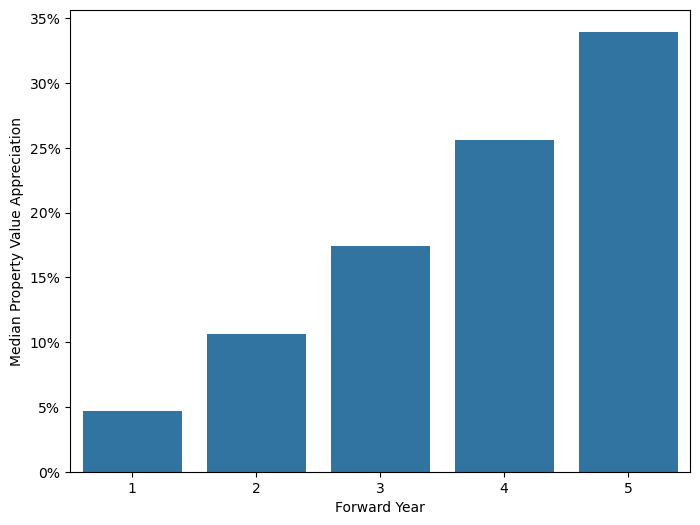

In [29]:
toPlot = (parcels[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].median() * 100).reset_index().assign(Delta = [1, 2, 3, 4, 5])

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'Delta', y = 0)
plt.xlabel('Forward Year')
plt.ylabel('Median Property Value Appreciation')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}%'))
plt.savefig(images + 'median_property_value_appreciation_by_year.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [11]:
parcels[['pct_delta_1', 'pct_delta_2', 'pct_delta_3', 'pct_delta_4', 'pct_delta_5']].mean() * 100

pct_delta_1   104.47
pct_delta_2    92.51
pct_delta_3   103.44
pct_delta_4   114.97
pct_delta_5   133.93
dtype: float64

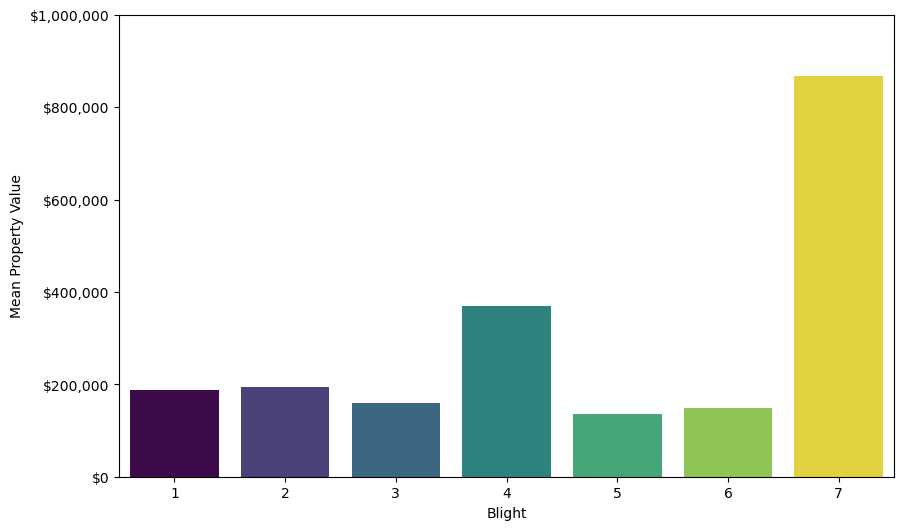

In [35]:
parcels['blight_sqrt'] = parcels['blight_sqrt'].astype(str)

plt.figure(figsize = (10, 6))

color_discrete_map = {
    '1': '#440154',
    '2': '#443983',
    '3': '#31688e',
    '4': '#21918c',
    '5': '#35b779',
    '6': '#90d743',
    '7': '#fde725'
}

sns.barplot((
    parcels
    .groupby('blight_sqrt')['values_smoothed'].mean()
    .reset_index()
    .rename(columns = {'blight_sqrt': 'Blight'})
    .melt(id_vars = 'Blight')
), x = 'Blight', y = 'value', hue = 'Blight', palette = color_discrete_map)

plt.ylabel('Mean Property Value')
locs, labels = plt.yticks()
plt.yticks(locs, [f'${int(val):,}' for val in locs])

plt.show()

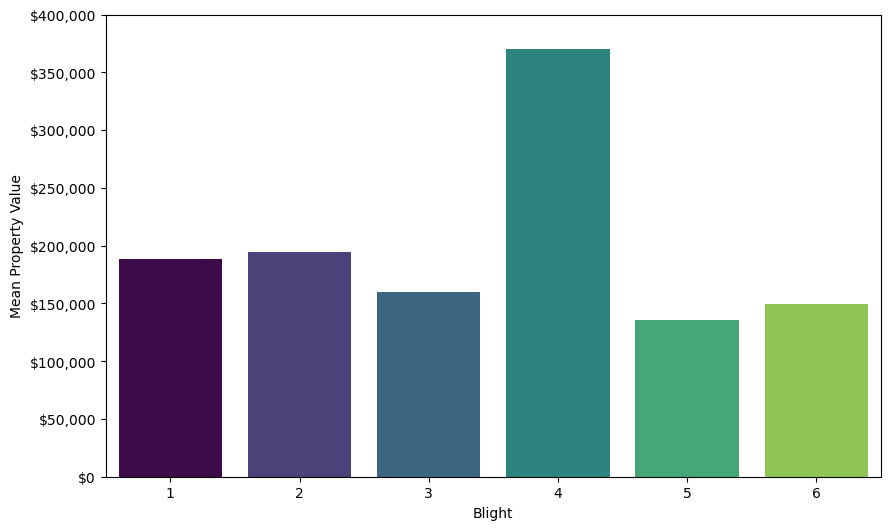

In [36]:
parcels['blight_sqrt'] = parcels['blight_sqrt'].astype(str)

plt.figure(figsize = (10, 6))

color_discrete_map = {
    '1': '#440154',
    '2': '#443983',
    '3': '#31688e',
    '4': '#21918c',
    '5': '#35b779',
    '6': '#90d743',
    '7': '#fde725'
}

sns.barplot((
    parcels.loc[parcels['blight_sqrt'] != '7']
    .groupby('blight_sqrt')['values_smoothed'].mean()
    .reset_index()
    .rename(columns = {'blight_sqrt': 'Blight'})
    .melt(id_vars = 'Blight')
), x = 'Blight', y = 'value', hue = 'Blight', palette = color_discrete_map)

plt.ylabel('Mean Property Value')
locs, labels = plt.yticks()
plt.yticks(locs, [f'${int(val):,}' for val in locs])

plt.show()

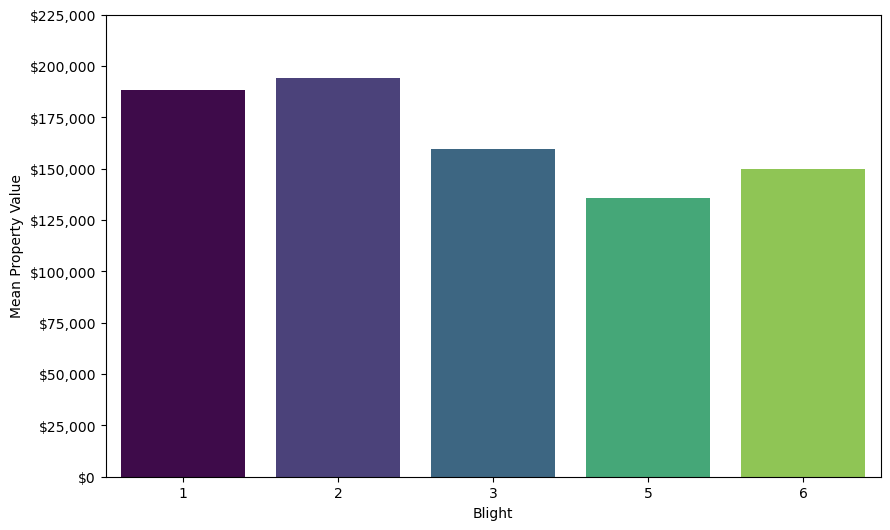

In [37]:
parcels['blight_sqrt'] = parcels['blight_sqrt'].astype(str)

plt.figure(figsize = (10, 6))

color_discrete_map = {
    '1': '#440154',
    '2': '#443983',
    '3': '#31688e',
    '4': '#21918c',
    '5': '#35b779',
    '6': '#90d743',
    '7': '#fde725'
}

sns.barplot((
    parcels.loc[~parcels['blight_sqrt'].isin(['4', '7'])]
    .groupby('blight_sqrt')['values_smoothed'].mean()
    .reset_index()
    .rename(columns = {'blight_sqrt': 'Blight'})
    .melt(id_vars = 'Blight')
), x = 'Blight', y = 'value', hue = 'Blight', palette = color_discrete_map)

plt.ylabel('Mean Property Value')
locs, labels = plt.yticks()
plt.yticks(locs, [f'${int(val):,}' for val in locs])

plt.show()

In [38]:
model = smf.ols(formula = f'mean_value ~ C(blight_sqrt)', data = parcels_regression).fit()
print(f'R-Squared: {round(model.rsquared, 3)} | F-Statistic: {round(model.fvalue, 1)} | P-Value: {round(model.f_pvalue, 3)}')
anova_results = anova_lm(model)
print(anova_results)
print('\n')

R-Squared: 0.255 | F-Statistic: 8196.1 | P-Value: 0.0
                       df                   sum_sq                mean_sq  \
C(blight_sqrt)       6.00   965,677,730,555,301.00 160,946,288,425,883.50   
Residual       144,024.00 2,828,177,416,683,935.00      19,636,848,141.17   

                      F  PR(>F)  
C(blight_sqrt) 8,196.14    0.00  
Residual            NaN     NaN  




In [39]:
model = smf.ols(formula = f'mean_value ~ C(blight_sqrt)', data = parcels_regression.loc[parcels_regression['blight_sqrt'] != 7]).fit()
print(f'R-Squared: {round(model.rsquared, 3)} | F-Statistic: {round(model.fvalue, 1)} | P-Value: {round(model.f_pvalue, 3)}')
anova_results = anova_lm(model)
print(anova_results)
print('\n')

R-Squared: 0.175 | F-Statistic: 6060.8 | P-Value: 0.0
                       df                   sum_sq                mean_sq  \
C(blight_sqrt)       5.00   597,511,566,905,890.62 119,502,313,381,178.12   
Residual       143,068.00 2,820,927,422,164,154.00      19,717,389,088.85   

                      F  PR(>F)  
C(blight_sqrt) 6,060.76    0.00  
Residual            NaN     NaN  




In [41]:
model = smf.ols(formula = f'mean_value ~ C(blight_sqrt)', data = parcels_regression.loc[~parcels_regression['blight_sqrt'].isin([4, 7])]).fit()
print(f'R-Squared: {round(model.rsquared, 3)} | F-Statistic: {round(model.fvalue, 1)} | P-Value: {round(model.f_pvalue, 3)}')
anova_results = anova_lm(model)
print(anova_results)
print('\n')

R-Squared: 0.023 | F-Statistic: 768.6 | P-Value: 0.0
                       df                   sum_sq               mean_sq  \
C(blight_sqrt)       4.00    58,536,221,270,469.89 14,634,055,317,617.47   
Residual       131,444.00 2,502,800,950,512,959.00     19,040,815,484.26   

                    F  PR(>F)  
C(blight_sqrt) 768.56    0.00  
Residual          NaN     NaN  




In [44]:
delta = []
rsq = []
fstat = []
for i in range(5):
    i += 1
    model = smf.ols(formula = f'pct_delta_{i} ~ C(blight)', data = parcels.loc[parcels['year'] == 2020]).fit()
    delta.append(f'{i} Year(s)')
    rsq.append(model.rsquared)
    fstat.append(model.fvalue)
    print(f'Percent Delta {i}')
    print(f'R-Squared: {round(model.rsquared, 3)} | F-Statistic: {round(model.fvalue, 1)} | P-Value: {round(model.f_pvalue, 3)}')
    anova_results = anova_lm(model)
    print(anova_results)
    print('\n')
results = pd.DataFrame({
    'Percent Delta': delta,
    'R-Squared': rsq,
    'F-Statistic': fstat
})

Percent Delta 1
R-Squared: 0.011 | F-Statistic: 271.1 | P-Value: 0.0
                  df   sum_sq  mean_sq      F  PR(>F)
C(blight)       6.00    60.12    10.02 271.08    0.00
Residual  144,024.00 5,323.31     0.04    NaN     NaN


Percent Delta 2
R-Squared: 0.046 | F-Statistic: 1156.5 | P-Value: 0.0
                  df    sum_sq  mean_sq        F  PR(>F)
C(blight)       6.00    947.67   157.95 1,156.52    0.00
Residual  144,024.00 19,669.24     0.14      NaN     NaN


Percent Delta 3
R-Squared: 0.097 | F-Statistic: 2591.4 | P-Value: 0.0
                  df    sum_sq  mean_sq        F  PR(>F)
C(blight)       6.00  2,904.81   484.14 2,591.43    0.00
Residual  144,024.00 26,906.81     0.19      NaN     NaN


Percent Delta 4
R-Squared: 0.096 | F-Statistic: 2542.9 | P-Value: 0.0
                  df    sum_sq  mean_sq        F  PR(>F)
C(blight)       6.00  4,229.16   704.86 2,542.94    0.00
Residual  144,024.00 39,921.10     0.28      NaN     NaN


Percent Delta 5
R-Squared: 0.112 | F-S

In [45]:
results

,Percent Delta,R-Squared,F-Statistic
0,1 Year(s),0.01,271.08
1,2 Year(s),0.05,"1,156.52"
2,3 Year(s),0.10,"2,591.43"
3,4 Year(s),0.10,"2,542.94"
4,5 Year(s),0.11,"3,024.15"


In [24]:
for i in range(1, 6):
    tukey = pairwise_tukeyhsd(
        endog = parcels.loc[parcels['year'] == 2020][f'pct_delta_{i}'],
        groups = parcels.loc[parcels['year'] == 2020]['blight'],
        alpha = 0.01
    )
    print(f'Percent Delta {i}')
    print(f'Tukey HSD: {tukey}')
    print('\n')

Percent Delta 1
Tukey HSD: Multiple Comparison of Means - Tukey HSD, FWER=0.01 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   0.0099    0.0  0.0039  0.0159   True
     1      3  -0.0477    0.0  -0.058 -0.0374   True
     1      4   0.0093    0.0  0.0028  0.0158   True
     1      5   0.0333    0.0   0.025  0.0416   True
     1      6  -0.0319    0.0 -0.0419  -0.022   True
     1      7  -0.0725    0.0 -0.0902 -0.0548   True
     2      3  -0.0576    0.0 -0.0678 -0.0473   True
     2      4  -0.0006 0.9999 -0.0071  0.0058  False
     2      5   0.0234    0.0  0.0151  0.0317   True
     2      6  -0.0418    0.0 -0.0517 -0.0319   True
     2      7  -0.0824    0.0    -0.1 -0.0647   True
     3      4   0.0569    0.0  0.0464  0.0675   True
     3      5    0.081    0.0  0.0692  0.0928   True
     3      6   0.0158 0.0005  0.0028  0.0287   True
     3      7  -0.0248 0.0002 -0.0443 -0.0053   True
     4      5    0.

In [46]:
parcels.loc[parcels['year'] == 2020].groupby('blight')[[f'pct_delta_{i + 1}' for i in range(5)]].median().reset_index().rename(columns = {'blight': 'Blight'})

,Blight,pct_delta_1,pct_delta_2,pct_delta_3,pct_delta_4,pct_delta_5
0,0,0.07,0.18,0.54,0.64,0.68
1,1,0.05,0.13,0.18,0.22,0.28
2,2,0.05,0.15,0.22,0.29,0.36
3,3,-0.01,-0.11,-0.09,-0.12,-0.11
4,4,0.04,0.12,0.14,0.20,0.27
5,5,-0.04,-0.05,-0.05,-0.03,0.07
6,6,0.07,0.18,0.37,0.48,0.68


In [47]:
parcels.loc[parcels['year'] == 2020].groupby('blight')[[f'pct_delta_{i + 1}' for i in range(5)]].mean().reset_index().rename(columns = {'blight': 'Blight'})

,Blight,pct_delta_1,pct_delta_2,pct_delta_3,pct_delta_4,pct_delta_5
0,0,0.10,0.46,0.75,0.93,1.07
1,1,0.06,0.15,0.21,0.26,0.29
2,2,0.07,0.20,0.28,0.36,0.40
3,3,-0.01,-0.11,-0.09,-0.13,-0.12
4,4,0.06,0.13,0.17,0.23,0.29
5,5,0.00,0.13,0.25,0.30,0.28
6,6,0.10,0.27,0.46,0.56,0.74
